# Main Pipeline — Breast Ultrasound Image Classification

## Run each cell to execute the pipeline step by step

The functions are imported from the src/ modules:
- src.eda → run_eda()
- src.preprocessing → run_preprocessing()
- src.training → run_training()
- src.evaluation → run_evaluation()

You can run them in order OR skip any step.

---
## Import all functions

In [5]:
from src.datafetch import run_eda
from src.datapreprocessing import run_preprocessing
from src.datatraining import run_training
from src.dataevalution import run_evaluation

print('\n' + '=' * 70)
print('  BREAST ULTRASOUND IMAGE CLASSIFICATION')
print('  M7016H Final Project')
print('=' * 70)
print('\nAll functions imported successfully!')
print()


  BREAST ULTRASOUND IMAGE CLASSIFICATION
  M7016H Final Project

All functions imported successfully!



---
## Exploratory Data Analysis

This will:
- Print image counts per class
- Display 4 sample images from each class
- Save Figure 1


[STEP 1/4] Exploratory Data Analysis

  EXPLORATORY DATA ANALYSIS (EDA)

Image counts:
  Benign    : 437 images  (56.0%)
  Malignant : 210 images  (26.9%)
  Normal    : 133 images  (17.1%)
  TOTAL     : 780 images

Class imbalance: YES → will use WeightedRandomSampler during training

✓ Loaded 4 benign samples
✓ Loaded 4 malignant samples
✓ Loaded 4 normal samples


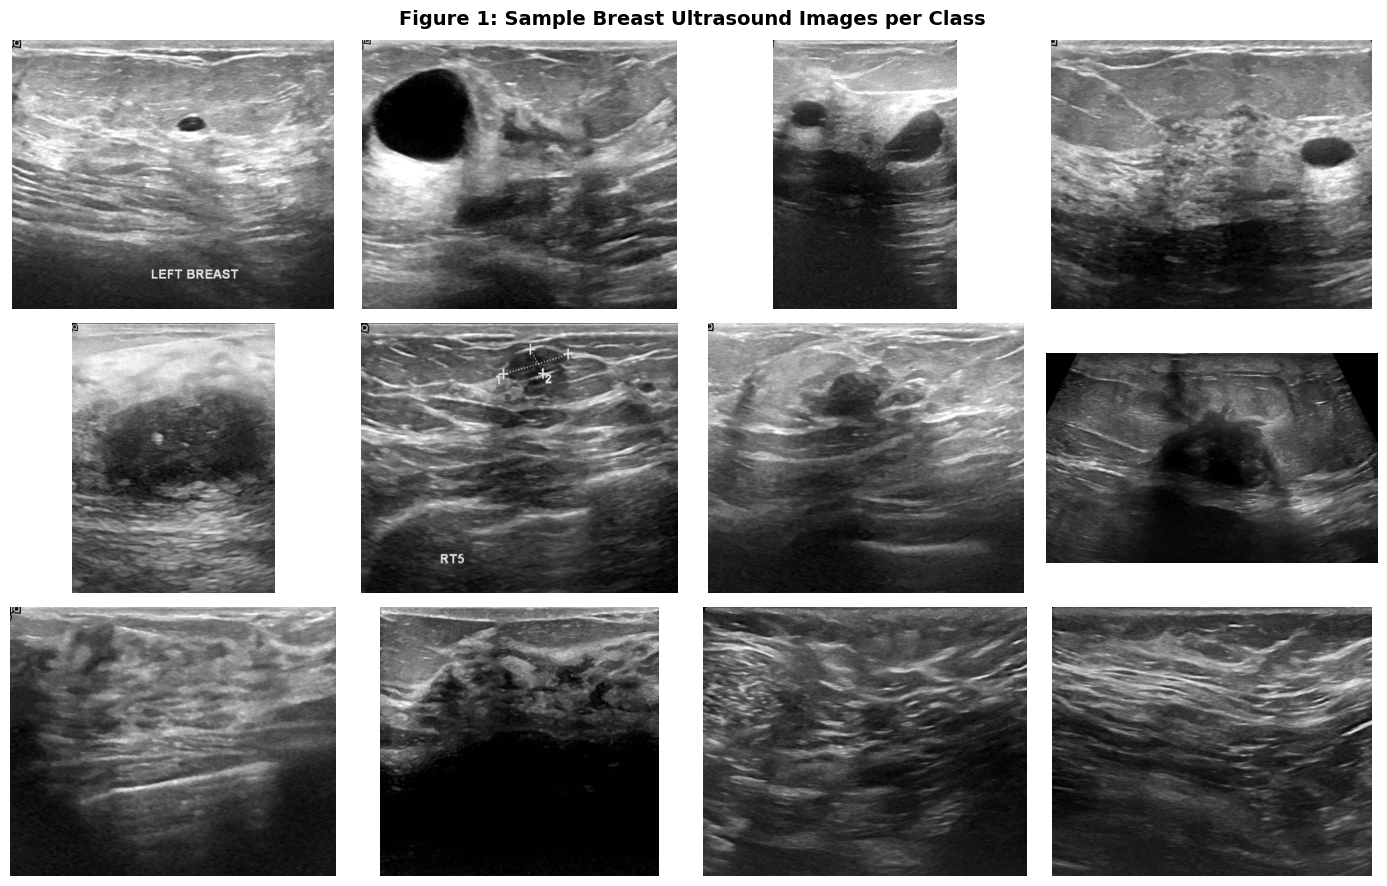


✓ Figure 1 saved → outputs/figures/fig1_sample_images.png

  EDA Complete



In [6]:
print('\n[STEP 1/4] Exploratory Data Analysis')
run_eda()

---
## Preprocessing & Train/Val/Test Split

This will:
- Split raw data into train (70%), val (15%), test (15%)
- Create folder structure: data/processed/train/val/test
- Verify with PyTorch ImageFolder
- Print summary table

In [8]:
print('\n[STEP 2/4] Preprocessing & Train/Val/Test Split')
run_preprocessing()


[STEP 2/4] Preprocessing & Train/Val/Test Split

  PREPROCESSING & TRAIN/VAL/TEST SPLIT

Split ratios : 70% / 15% / 15%
Random seed  : 42

Processing classes...
  benign       → train=305  val=65  test=67  total=437
  malignant    → train=147  val=31  test=32  total=210
  normal       → train=93  val=19  test=21  total=133

  Split       Benign   Malignant    Normal    Total
  train          305         147        93      545
  val             65          31        19      115
  test            67          32        21      120
  TOTAL          437         210       133      780

Verifying with PyTorch ImageFolder...
  Train dataset : 545 images
  Val dataset   : 115 images
  Test dataset  : 120 images
  Classes       : ['benign', 'malignant', 'normal']
  Sample shape  : torch.Size([3, 224, 224])  (3 channels, 224×224)

✓ Split complete and verified!



---
##  Model Training

This will:
- Build ResNet-18 model
- Stage 1: Train head only (frozen backbone) for 15 epochs
- Stage 2: Fine-tune all layers for up to 25 epochs
- Monitor validation loss, save best checkpoint
- Generate Figure 3 (training curves)

**⚠️ WARNING:** This takes 10-20 minutes on CPU, 2-3 minutes on GPU


[STEP 3/4] Model Training

Consider running on Google Colab GPU for speed.


Using device: cpu

Train dataset: 545 images
Val dataset  : 115 images
Train loader : 18 batches
Val loader   : 4 batches
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sowmy/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 18.0MB/s]



  STAGE 1: Training classification head (backbone frozen)


Epoch  1/15  Train Loss: 1.0686  Train Acc: 0.367  |  Val Loss: 1.4613  Val Acc: 0.270
    Val loss improved → saved to outputs/models/best_model_stage1.pth


Epoch  2/15  Train Loss: 0.9604  Train Acc: 0.455  |  Val Loss: 1.7782  Val Acc: 0.287
    No improvement (1/7)


...

Epoch 10/25  Train Loss: 0.0848  Train Acc: 0.958  |  Val Loss: 0.6719  Val Acc: 0.826
    No improvement (3/7)


Epoch 11/25  Train Loss: 0.0614  Train Acc: 0.967  |  Val Loss: 0.6649  Val Acc: 0.783
    No improvement (4/7)


Epoch 12/25  Train Loss: 0.0597  Train Acc: 0.969  |  Val Loss: 0.7807  Val Acc: 0.783
    No improvement (5/7)


Epoch 13/25  Train Loss: 0.0639  Train Acc: 0.967  |  Val Loss: 0.5413  Val Acc: 0.852
    No improvement (6/7)


Epoch 14/25  Train Loss: 0.0458  Train Acc: 0.983  |  Val Loss: 0.5261  Val Acc: 0.817
    No improvement (7/7)
    Early stopping triggered!
Stopped early at epoch 14

Stage 2 complete!
Training log saved → outputs/logs/training_log.csv


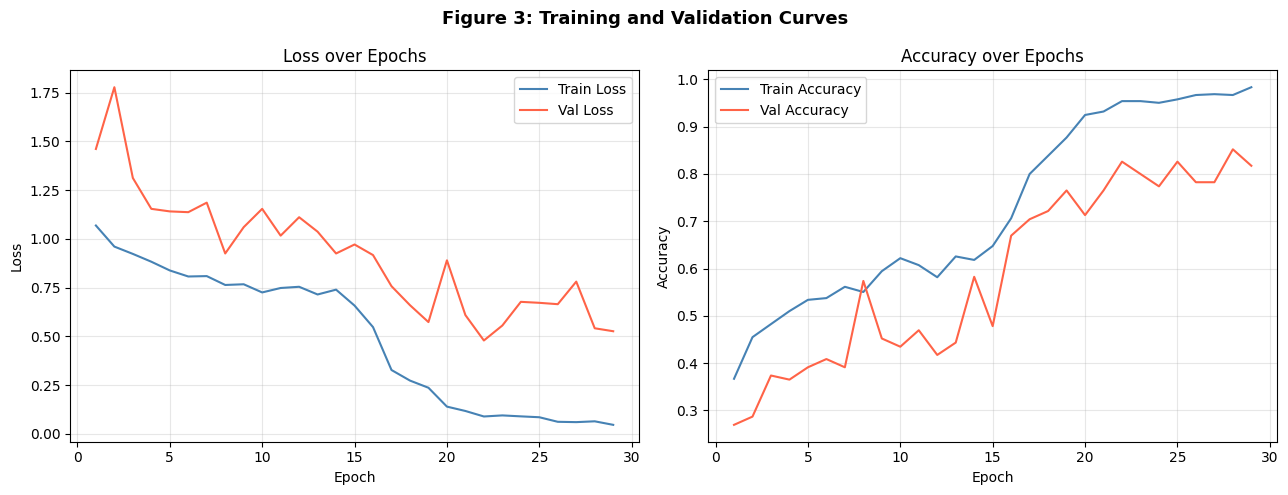

Figure 3 saved → outputs/figures/fig3_training_curves.png

✓ Best model loaded and ready for evaluation!



In [9]:
print('\n[STEP 3/4] Model Training')
print('\nWarning: This may take 10-20 minutes on CPU')
print('Consider running on Google Colab GPU for speed.\n')
run_training()

---
## Model Evaluation

This will:
- Load best trained model
- Run predictions on validation set (sanity check)
- Run predictions on test set (final results)
- Generate Figure 4 (confusion matrix)
- Generate Figure 5 (ROC curves)
- Print Table 2 (all metrics per class)

**⚠️ WARNING:** Run this ONLY ONCE. The test set is your final evaluation.


[STEP 4/4] Model Evaluation

The test set gives your final, unbiased performance metrics.


Using device: cpu
Val dataset  : 115 images
Test dataset : 120 images

  EVALUATION

Running predictions on validation set...
  RESULTS ON VALIDATION SET

Classification Report:

              precision    recall  f1-score   support

      benign       0.87      0.82      0.84        65
   malignant       0.71      0.81      0.76        31
      normal       0.89      0.89      0.89        19

    accuracy                           0.83       115
   macro avg       0.83      0.84      0.83       115
weighted avg       0.83      0.83      0.83       115

Per-class Sensitivity and Specificity:
Class           Sensitivity    Specificity
------------------------------------------
benign                0.815          0.840
malignant             0.806          0.881
normal                0.895          0.979

Overall Accuracy : 0.8261
Macro AUROC      : 0.9389



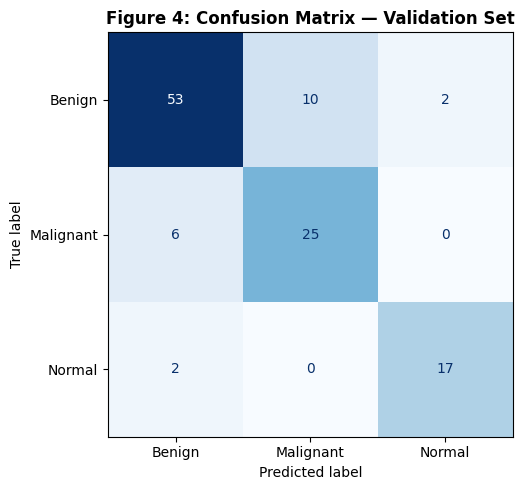

Figure 4 saved → outputs/figures/fig4_confusion_matrix_validation.png


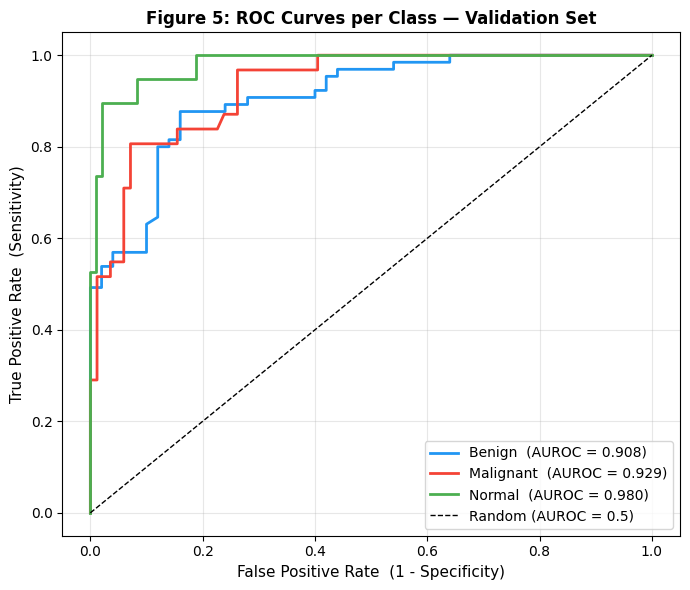

Figure 5 saved → outputs/figures/fig5_roc_curves_validation.png

Running predictions on TEST set...
(This is the final result — run only once!)
  RESULTS ON TEST SET

Classification Report:

              precision    recall  f1-score   support

      benign       0.90      0.90      0.90        67
   malignant       0.78      0.88      0.82        32
      normal       0.88      0.71      0.79        21

    accuracy                           0.86       120
   macro avg       0.85      0.83      0.84       120
weighted avg       0.86      0.86      0.86       120

Per-class Sensitivity and Specificity:
Class           Sensitivity    Specificity
------------------------------------------
benign                0.896          0.868
malignant             0.875          0.909
normal                0.714          0.980

Overall Accuracy : 0.8583
Macro AUROC      : 0.9591



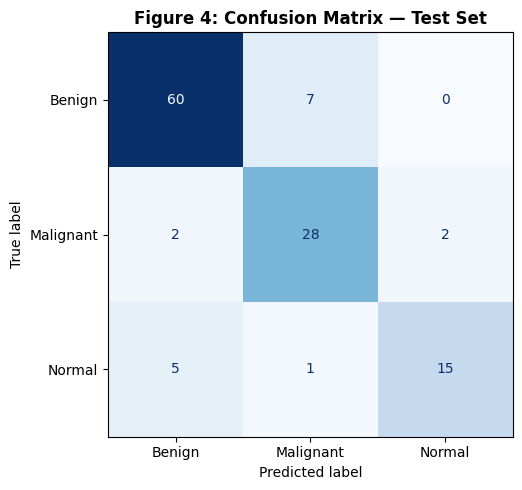

Figure 4 saved → outputs/figures/fig4_confusion_matrix_test.png


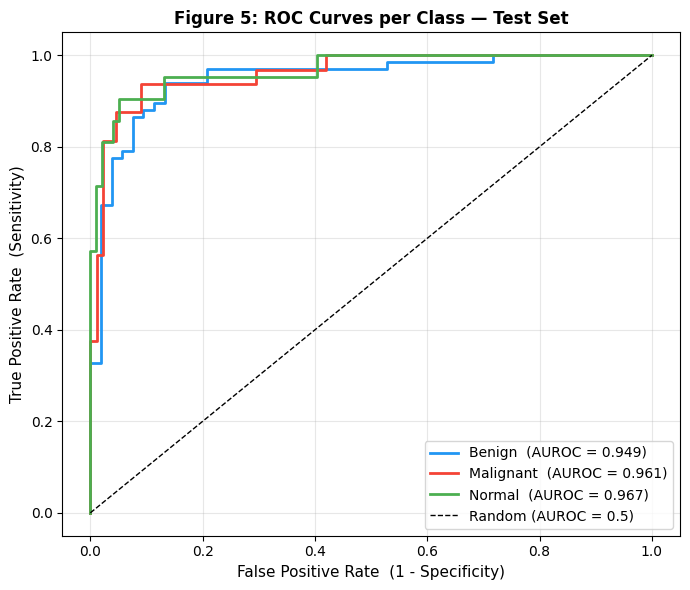

Figure 5 saved → outputs/figures/fig5_roc_curves_test.png

  TABLE 2: Test Set Performance Metrics
Class          Sensitivity   Specificity   Precision        F1     AUROC      N
--------------------------------------------------------------------------------
benign               0.896         0.868       0.896     0.896     0.949     67
malignant            0.875         0.909       0.778     0.824     0.961     32
normal               0.714         0.980       0.882     0.789     0.967     21
--------------------------------------------------------------------------------

Overall Accuracy : 0.858  (85.8%)
Macro AUROC      : 0.959

✓ Evaluation complete!



In [10]:
print('\n[STEP 4/4] Model Evaluation')
print('\nWarning: Run this ONLY ONCE')
print('The test set gives your final, unbiased performance metrics.\n')
run_evaluation()

---
## Summary

In [11]:
print('\n' + '=' * 70)
print('  ✓ COMPLETE PIPELINE FINISHED')
print('=' * 70)
print('\nGenerated files for your report:')
print('  Figure 1 → outputs/figures/fig1_sample_images.png')
print('  Figure 3 → outputs/figures/fig3_training_curves.png')
print('  Figure 4 → outputs/figures/fig4_confusion_matrix_test.png')
print('  Figure 5 → outputs/figures/fig5_roc_curves_test.png')
print('  Best Model → outputs/models/best_model_stage2.pth')
print('  Training Log → outputs/logs/training_log.csv')
print('\nNext: Write your report using these figures and metrics!')
print('=' * 70 + '\n')


  ✓ COMPLETE PIPELINE FINISHED

Generated files for your report:
  Figure 1 → outputs/figures/fig1_sample_images.png
  Figure 3 → outputs/figures/fig3_training_curves.png
  Figure 4 → outputs/figures/fig4_confusion_matrix_test.png
  Figure 5 → outputs/figures/fig5_roc_curves_test.png
  Best Model → outputs/models/best_model_stage2.pth
  Training Log → outputs/logs/training_log.csv

Next: Write your report using these figures and metrics!

